# Analyse Kazakhstan results (Part 2)

Run this notebook from the **PyPSA-Earth project root** — the directory that contains `Snakefile` and `results/KZ/`. Paths such as `results/KZ/networks/...` are relative to that folder.

If you downloaded this file from the documentation, copy it to the project root before running. Do not run it from `doc/tutorials/use-cases/`.

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

# Load the network (path relative to project root)
n = pypsa.Network("results/KZ/networks/elec_s_10_ec_lcopt_6h.nc")
print(n)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_6h.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


PyPSA Network
Components:
 - Bus: 30
 - Carrier: 23
 - Generator: 65
 - Line: 10
 - Link: 40
 - Load: 10
 - StorageUnit: 2
 - Store: 20
Snapshots: 1460


### Annual demand

In [2]:
# Compute total annual demand
weights = n.snapshot_weightings.generators

total_demand_TWh = n.loads_t.p_set.multiply(weights, axis=0).sum().sum() / 1e6
print(f"Total annual demand: {total_demand_TWh:.1f} TWh")

Total annual demand: 106.8 TWh


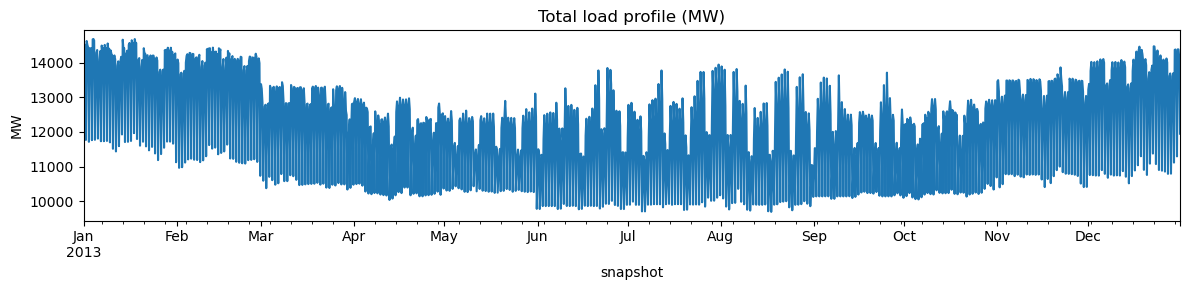

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
n.loads_t.p_set.sum(axis=1).plot(ax=ax, title="Total load profile (MW)")
ax.set_ylabel("MW")
fig.tight_layout()

### Installed capacities

In [7]:
# Get installed capacities
caps = n.statistics()["Installed Capacity"].dropna() / 1e3  # GW
print(caps.sort_values(ascending=False).to_string())

Line         Ac                    31.191464
Generator    Load shedding         17.614600
             Coal                  11.722188
             Combined-Cycle Gas     2.427000
StorageUnit  Reservoir & Dam        2.337178
Generator    Onshore Wind           1.379912
             Solar                  1.204659
             Oil                    1.139393
             Run of River           0.126000
Link         H2 electrolysis        0.000000
             H2 fuel cell           0.000000
             battery charger        0.000000
             battery discharger     0.000000
Load         -                      0.000000
Store        Battery Storage        0.000000
             H2                     0.000000


In [8]:
stat = n.statistics()[["Installed Capacity", "Optimal Capacity"]].dropna() / 1e3  # GW
stat["New build"] = stat["Optimal Capacity"] - stat["Installed Capacity"]
print(stat.sort_values("Optimal Capacity", ascending=False).to_string())

                                Installed Capacity  Optimal Capacity  New build
Store       H2                            0.000000         39.930095  39.930095
Line        Ac                           31.191464         32.477218   1.285755
Generator   Solar                         1.204659         20.065136  18.860478
            Load shedding                17.614600         17.614600   0.000000
            Coal                         11.722188         11.722188   0.000000
Store       Battery Storage               0.000000          8.448338   8.448338
Generator   Onshore Wind                  1.379912          6.188800   4.808888
            Combined-Cycle Gas            2.427000          2.427000   0.000000
StorageUnit Reservoir & Dam               2.337178          2.337178   0.000000
Generator   Oil                           1.139393          1.139393   0.000000
Link        H2 fuel cell                  0.000000          0.872254   0.872254
            battery discharger          

carrier
solar         20.065136
coal          11.722188
onwind         6.188800
CCGT           2.427000
oil            1.139393
ror            0.126000
offwind-ac     0.000000
offwind-dc     0.000000


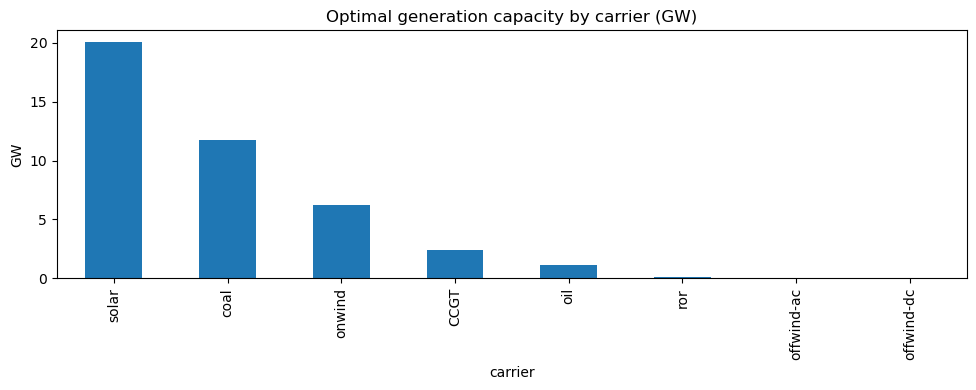

In [9]:
gen_caps = (
    n.generators.loc[n.generators.carrier != "load shedding"]  # exclude load shedding
    .groupby("carrier")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    / 1e3  # GW
)
print(gen_caps.to_string())
fig, ax = plt.subplots(figsize=(10, 4))
gen_caps.plot.bar(ax=ax, title="Optimal generation capacity by carrier (GW)")
ax.set_ylabel("GW")
fig.tight_layout()

### Annual generation by carrier

carrier
coal             62.541959
solar            25.396875
onwind           14.809795
hydro             2.831600
ror               0.777337
CCGT              0.629117
load shedding     0.000000
offwind-ac        0.000000
offwind-dc        0.000000
oil               0.000000


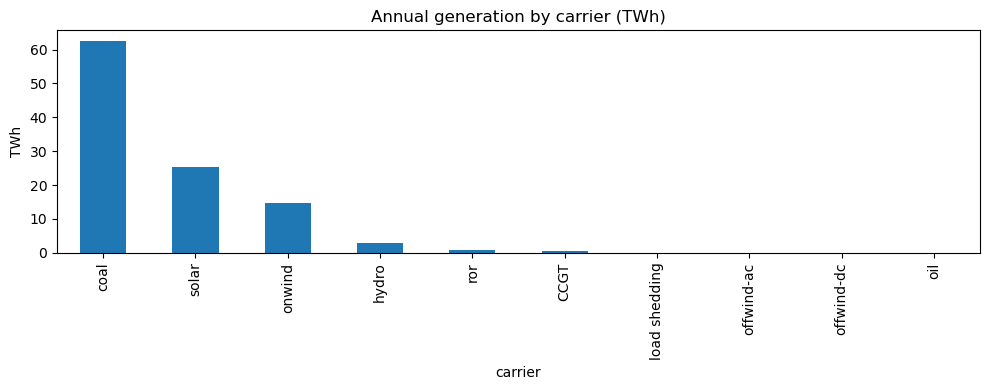

In [10]:
# Estimate generation mix
gen_mwh = (
    n.generators_t.p.multiply(weights, axis=0).sum().groupby(n.generators.carrier).sum()
)

su_mwh = (
    n.storage_units_t.p.multiply(weights, axis=0)
    .sum()
    .groupby(n.storage_units.carrier)
    .sum()
)

gen = ((gen_mwh.add(su_mwh, fill_value=0)) / 1e6).sort_values(ascending=False)  # TWh
print(gen.to_string())
fig, ax = plt.subplots(figsize=(10, 4))
gen.plot.bar(ax=ax, title="Annual generation by carrier (TWh)")
ax.set_ylabel("TWh")
fig.tight_layout()
fig.savefig("doc/img/kz_annual_generation.png", dpi=150)

In [11]:
supply = n.statistics()["Supply"].dropna() / 1e6  # TWh
print(supply.sort_values(ascending=False).to_string())

Line         Ac                    90.151409
Generator    Coal                  62.541959
             Solar                 25.396875
             Onshore Wind          14.809795
StorageUnit  Reservoir & Dam        2.831600
Generator    Run of River           0.777337
             Combined-Cycle Gas     0.629117
Link         battery charger        0.492253
Store        Battery Storage        0.492253
Link         battery discharger     0.472563
             H2 electrolysis        0.165704
Store        H2                     0.165704
Link         H2 fuel cell           0.082852
Generator    Load shedding          0.000000
             Oil                    0.000000
Load         -                      0.000000


### Capacity factors

In [12]:
gen_cf = (
    n.generators_t.p.divide(n.generators.p_nom_opt.clip(lower=1), axis=1)
    .mean()
    .groupby(n.generators.carrier)
    .mean()
)

su_cf = (
    n.storage_units_t.p.divide(n.storage_units.p_nom_opt.clip(lower=1), axis=1)
    .mean()
    .groupby(n.storage_units.carrier)
    .mean()
)

cf = gen_cf.add(su_cf, fill_value=0).sort_values(ascending=False)
print(cf.to_string())

carrier
ror              0.704262
coal             0.246406
onwind           0.240277
hydro            0.135637
solar            0.096808
CCGT             0.025536
load shedding    0.000000
offwind-ac       0.000000
offwind-dc       0.000000
oil              0.000000
